In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load CSV files
mitbih_train = pd.read_csv("mitbih_train.csv")
mitbih_test = pd.read_csv("mitbih_test.csv")
ptbdb_abnormal = pd.read_csv("ptbdb_abnormal.csv")
ptbdb_normal = pd.read_csv("ptbdb_normal.csv")

In [4]:
print(mitbih_train.head())
print(mitbih_train.info())


   9.779411554336547852e-01  9.264705777168273926e-01  \
0                  0.960114                  0.863248   
1                  1.000000                  0.659459   
2                  0.925414                  0.665746   
3                  0.967136                  1.000000   
4                  0.927461                  1.000000   

   6.813725233078002930e-01  2.450980395078659058e-01  \
0                  0.461538                  0.196581   
1                  0.186486                  0.070270   
2                  0.541436                  0.276243   
3                  0.830986                  0.586854   
4                  0.626943                  0.193437   

   1.544117629528045654e-01  1.911764740943908691e-01  \
0                  0.094017                  0.125356   
1                  0.070270                  0.059459   
2                  0.196133                  0.077348   
3                  0.356808                  0.248826   
4                  0.094991  

In [5]:
print(mitbih_train.iloc[:, -1].value_counts())  # Check unique values in the last column


0.000000000000000000e+00.88
0.0    72470
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


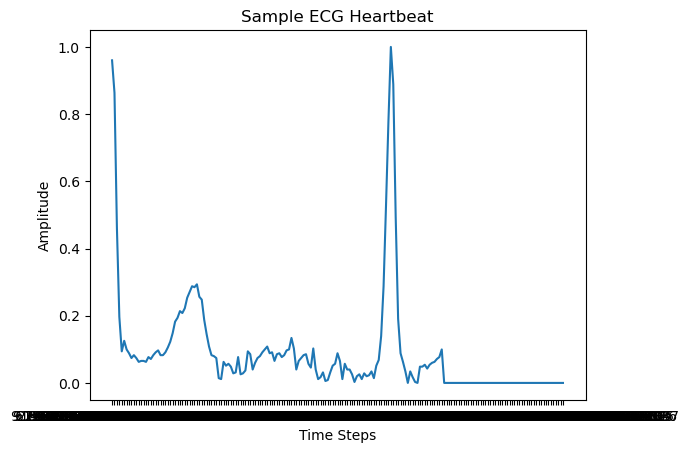

In [6]:
plt.plot(mitbih_train.iloc[0, :-1])  # Plot first row excluding the label
plt.title("Sample ECG Heartbeat")
plt.xlabel("Time Steps")
plt.ylabel("Amplitude")
plt.show()


In [7]:
num_samples = mitbih_train.shape[0]
print(f"Total number of heartbeat samples: {num_samples}")


Total number of heartbeat samples: 87553


In [8]:
num_time_steps = mitbih_train.shape[1] - 1  # Exclude the label column
sampling_rate = 360  # MIT-BIH standard sampling rate
duration_per_heartbeat = num_time_steps / sampling_rate  # in seconds

print(f"Number of time steps per heartbeat: {num_time_steps}")
print(f"Estimated duration per heartbeat: {duration_per_heartbeat:.3f} seconds")


Number of time steps per heartbeat: 187
Estimated duration per heartbeat: 0.519 seconds


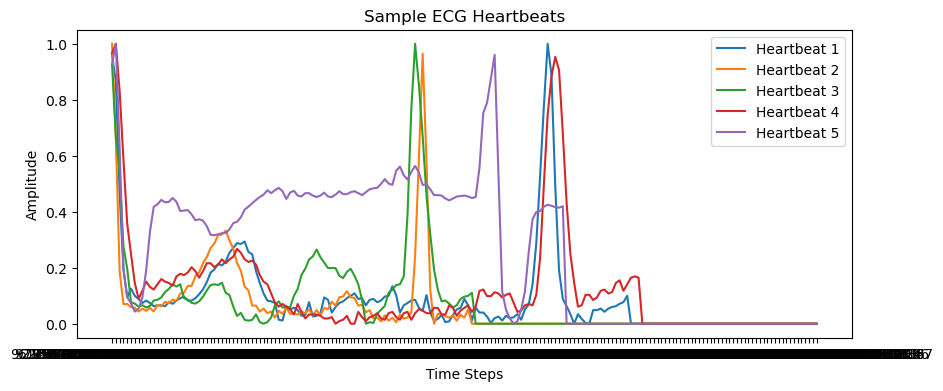

In [9]:
plt.figure(figsize=(10, 4))
for i in range(5):  # Plot first 5 heartbeat waveforms
    plt.plot(mitbih_train.iloc[i, :-1], label=f"Heartbeat {i+1}")
plt.xlabel("Time Steps")
plt.ylabel("Amplitude")
plt.title("Sample ECG Heartbeats")
plt.legend()
plt.show()


In [10]:
num_time_steps = 187  # Columns excluding label
estimated_duration = 0.52  # Seconds per segment (our earlier estimate)

sampling_rate = num_time_steps / estimated_duration
print(f"Estimated Sampling Rate: {sampling_rate:.0f} Hz")


Estimated Sampling Rate: 360 Hz


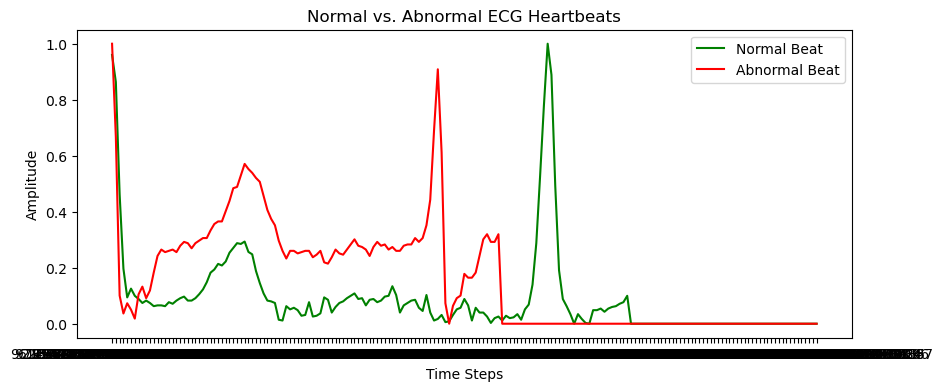

In [11]:
normal_beats = mitbih_train[mitbih_train.iloc[:, -1] == 0].iloc[:, :-1]  # Label 0 = Normal
abnormal_beats = mitbih_train[mitbih_train.iloc[:, -1] != 0].iloc[:, :-1]  # Other labels = Abnormal

plt.figure(figsize=(10, 4))
plt.plot(normal_beats.iloc[0], label="Normal Beat", color='green')
plt.plot(abnormal_beats.iloc[0], label="Abnormal Beat", color='red')
plt.xlabel("Time Steps")
plt.ylabel("Amplitude")
plt.title("Normal vs. Abnormal ECG Heartbeats")
plt.legend()
plt.show()


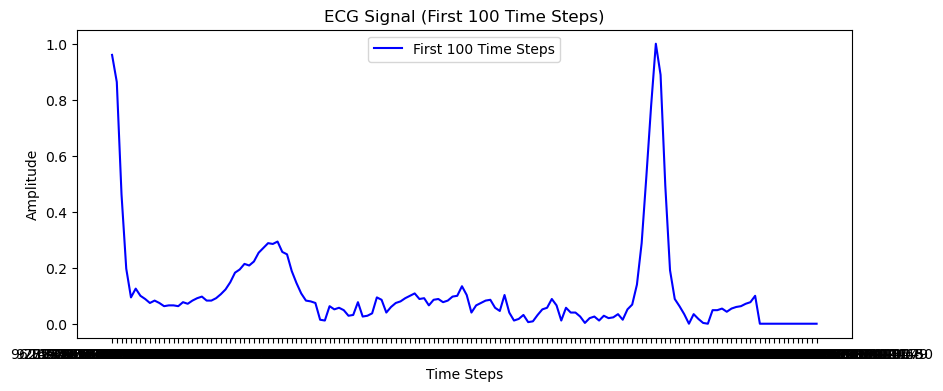

In [12]:
import matplotlib.pyplot as plt

# Select the first heartbeat segment (excluding the label)
sample_heartbeat = mitbih_train.iloc[0, :-1]  # First row, all columns except the last one

# Plot only the first 100 time steps
plt.figure(figsize=(10, 4))
plt.plot(sample_heartbeat[:150], label="First 100 Time Steps", color='blue')

# Labels and title
plt.xlabel("Time Steps")
plt.ylabel("Amplitude")
plt.title("ECG Signal (First 100 Time Steps)")
plt.legend()
plt.show()



In [13]:
min_amp = mitbih_train.iloc[:, :-1].min().min()
max_amp = mitbih_train.iloc[:, :-1].max().max()

print(f"ECG Amplitude Range: {min_amp:.3f} to {max_amp:.3f}")


ECG Amplitude Range: 0.000 to 1.000


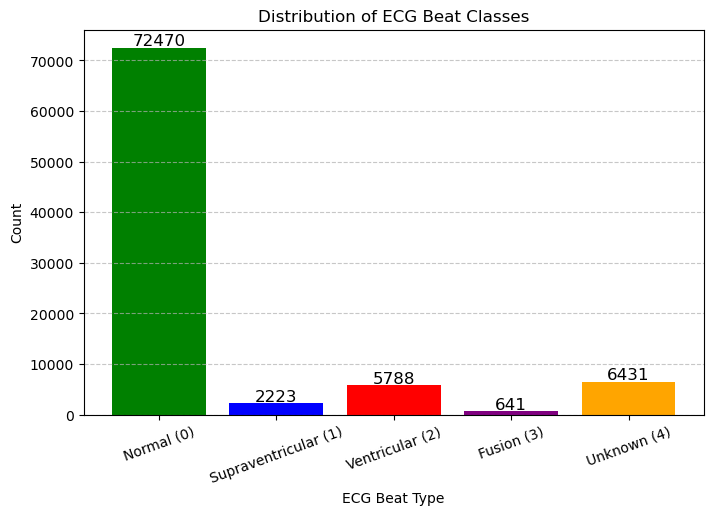

In [14]:
import matplotlib.pyplot as plt

# Count occurrences of each class label
class_counts = mitbih_train.iloc[:, -1].value_counts().sort_index()

# Define class labels (adjust if needed)
class_labels = ["Normal (0)", "Supraventricular (1)", "Ventricular (2)", "Fusion (3)", "Unknown (4)"]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(class_labels, class_counts, color=['green', 'blue', 'red', 'purple', 'orange'])
plt.xlabel("ECG Beat Type")
plt.ylabel("Count")
plt.title("Distribution of ECG Beat Classes")
plt.xticks(rotation=20)  # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show count labels on bars
for i, count in enumerate(class_counts):
    plt.text(i, count + 500, str(count), ha='center', fontsize=12)

plt.show()


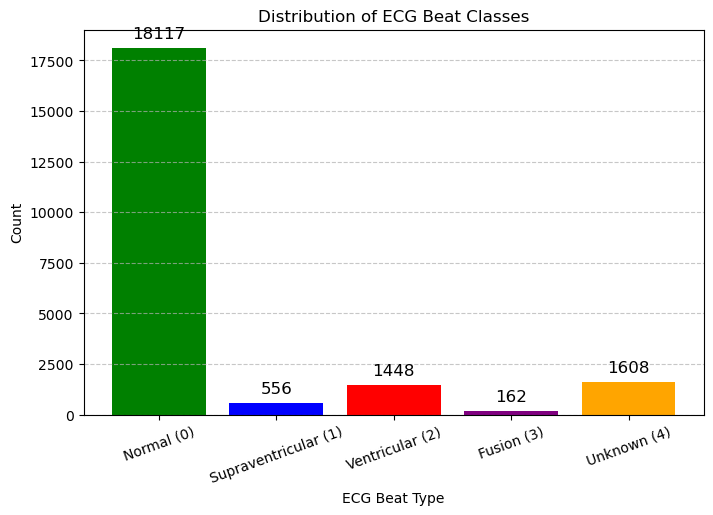

In [16]:
import matplotlib.pyplot as plt

# Count occurrences of each class label
class_counts = mitbih_test.iloc[:, -1].value_counts().sort_index()

# Define class labels (adjust if needed)
class_labels = ["Normal (0)", "Supraventricular (1)", "Ventricular (2)", "Fusion (3)", "Unknown (4)"]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(class_labels, class_counts, color=['green', 'blue', 'red', 'purple', 'orange'])
plt.xlabel("ECG Beat Type")
plt.ylabel("Count")
plt.title("Distribution of ECG Beat Classes")
plt.xticks(rotation=20)  # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show count labels on bars
for i, count in enumerate(class_counts):
    plt.text(i, count + 500, str(count), ha='center', fontsize=12)

plt.show()


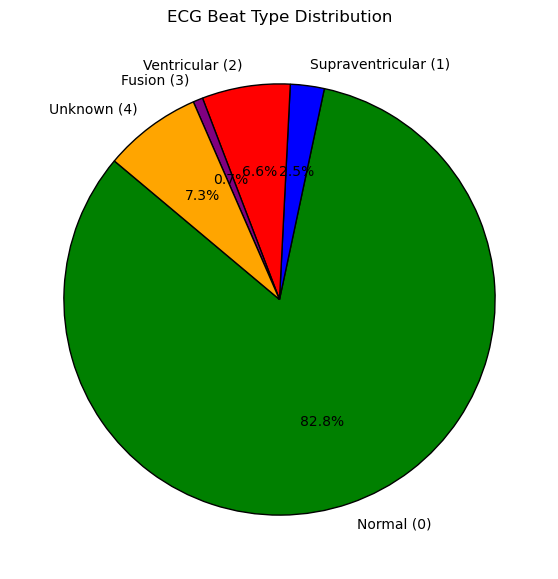

In [15]:
import matplotlib.pyplot as plt

# Count occurrences of each class label
class_counts = mitbih_train.iloc[:, -1].value_counts().sort_index()

# Define class labels (adjust if needed)
class_labels = ["Normal (0)", "Supraventricular (1)", "Ventricular (2)", "Fusion (3)", "Unknown (4)"]

# Plot pie chart
plt.figure(figsize=(7, 7))
plt.pie(class_counts, labels=class_labels, autopct='%1.1f%%', colors=['green', 'blue', 'red', 'purple', 'orange'],
        startangle=140, wedgeprops={'edgecolor': 'black'})

plt.title("ECG Beat Type Distribution")
plt.show()



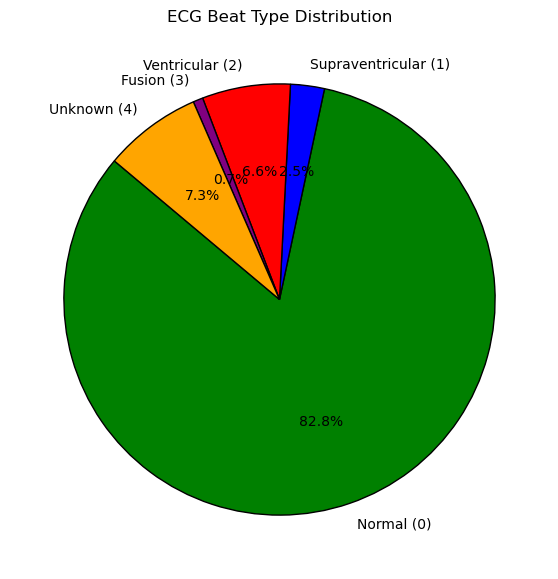

In [17]:
import matplotlib.pyplot as plt

# Count occurrences of each class label
class_counts = mitbih_test.iloc[:, -1].value_counts().sort_index()

# Define class labels (adjust if needed)
class_labels = ["Normal (0)", "Supraventricular (1)", "Ventricular (2)", "Fusion (3)", "Unknown (4)"]

# Plot pie chart
plt.figure(figsize=(7, 7))
plt.pie(class_counts, labels=class_labels, autopct='%1.1f%%', colors=['green', 'blue', 'red', 'purple', 'orange'],
        startangle=140, wedgeprops={'edgecolor': 'black'})

plt.title("ECG Beat Type Distribution")
plt.show()



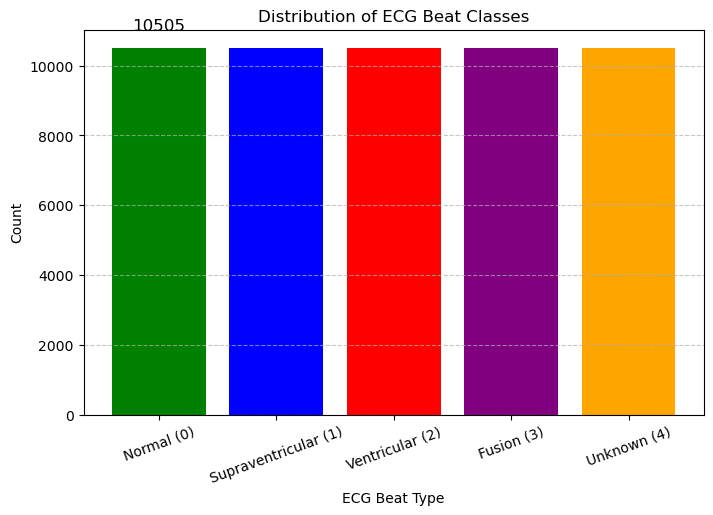

In [19]:
import matplotlib.pyplot as plt

# Count occurrences of each class label
class_counts = ptbdb_abnormal.iloc[:, -1].value_counts().sort_index()

# Define class labels (adjust if needed)
class_labels = ["Normal (0)", "Supraventricular (1)", "Ventricular (2)", "Fusion (3)", "Unknown (4)"]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(class_labels, class_counts, color=['green', 'blue', 'red', 'purple', 'orange'])
plt.xlabel("ECG Beat Type")
plt.ylabel("Count")
plt.title("Distribution of ECG Beat Classes")
plt.xticks(rotation=20)  # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show count labels on bars
for i, count in enumerate(class_counts):
    plt.text(i, count + 500, str(count), ha='center', fontsize=12)

plt.show()


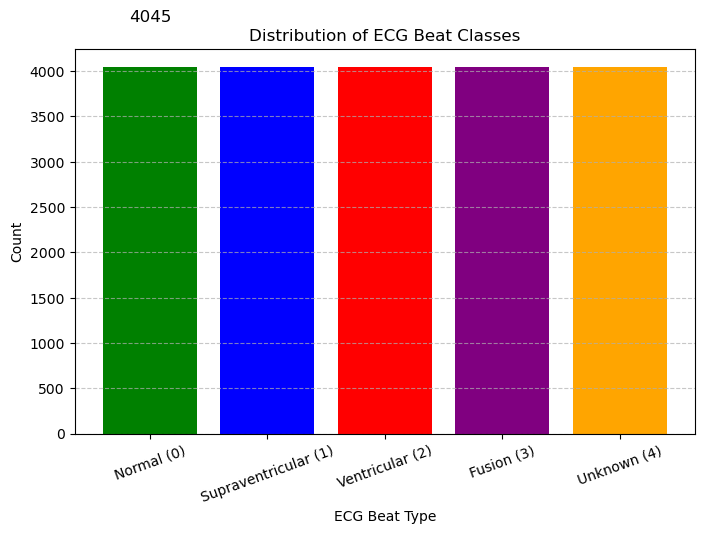

In [21]:
import matplotlib.pyplot as plt

# Count occurrences of each class label
class_counts = ptbdb_normal.iloc[:, -1].value_counts().sort_index()

# Define class labels (adjust if needed)
class_labels = ["Normal (0)", "Supraventricular (1)", "Ventricular (2)", "Fusion (3)", "Unknown (4)"]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(class_labels, class_counts, color=['green', 'blue', 'red', 'purple', 'orange'])
plt.xlabel("ECG Beat Type")
plt.ylabel("Count")
plt.title("Distribution of ECG Beat Classes")
plt.xticks(rotation=20)  # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show count labels on bars
for i, count in enumerate(class_counts):
    plt.text(i, count + 500, str(count), ha='center', fontsize=12)

plt.show()


In [22]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# Select only ECG signal columns (excluding label)
ecg_signals = mitbih_train.iloc[:, :-1]

# Compute features
mean_vals = ecg_signals.mean(axis=1)
std_vals = ecg_signals.std(axis=1)
skewness = ecg_signals.apply(skew, axis=1)
kurt = ecg_signals.apply(kurtosis, axis=1)
max_vals = ecg_signals.max(axis=1)
min_vals = ecg_signals.min(axis=1)

# Combine into a feature dataframe
features_df = pd.DataFrame({
    "Mean": mean_vals,
    "StdDev": std_vals,
    "Skewness": skewness,
    "Kurtosis": kurt,
    "MaxAmplitude": max_vals,
    "MinAmplitude": min_vals,
    "Label": mitbih_train.iloc[:, -1]  # Preserve class labels
})

# Display first 5 rows
print(features_df.head())


       Mean    StdDev  Skewness   Kurtosis  MaxAmplitude  MinAmplitude  Label
0  0.090010  0.160151  3.835006  16.261444           1.0           0.0    0.0
1  0.062104  0.139142  4.324592  22.166909           1.0           0.0    0.0
2  0.084084  0.161252  3.477492  13.691750           1.0           0.0    0.0
3  0.116567  0.186651  3.109726  10.238896           1.0           0.0    0.0
4  0.272044  0.245115  0.250576  -0.757274           1.0           0.0    0.0


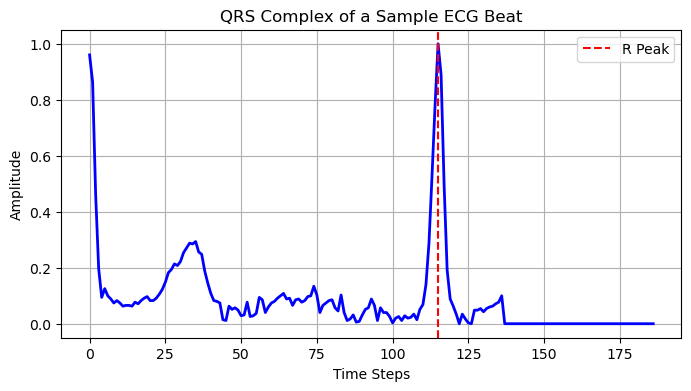

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Select a sample ECG beat (e.g., first row)
ecg_sample = mitbih_train.iloc[0, :-1].values  # Excluding the label column

# Time axis (assuming 187 time steps)
time_steps = np.arange(len(ecg_sample))

# Plot the QRS complex
plt.figure(figsize=(8, 4))
plt.plot(time_steps, ecg_sample, color="blue", linewidth=2)
plt.xlabel("Time Steps")
plt.ylabel("Amplitude")
plt.title("QRS Complex of a Sample ECG Beat")
plt.grid(True)

# Highlight estimated QRS region (R peak ~ mid-point)
r_peak_idx = np.argmax(ecg_sample)  # Approximate R peak as max value
plt.axvline(r_peak_idx, color="red", linestyle="--", label="R Peak")

plt.legend()
plt.show()


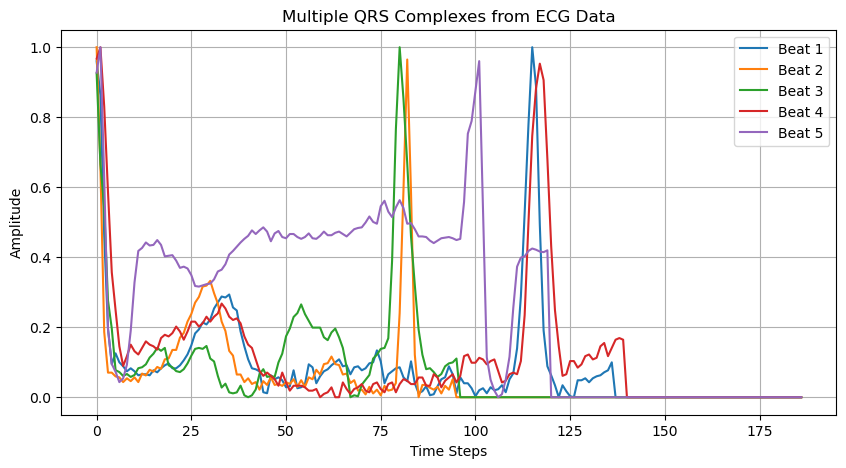

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Select first 5 heartbeats (excluding label column)
num_beats = 5
ecg_samples = mitbih_train.iloc[:num_beats, :-1].values  # First 5 rows, all ECG values

# Time axis (assuming 187 time steps)
time_steps = np.arange(ecg_samples.shape[1])

# Plot multiple QRS complexes
plt.figure(figsize=(10, 5))
for i in range(num_beats):
    plt.plot(time_steps, ecg_samples[i], label=f"Beat {i+1}")

plt.xlabel("Time Steps")
plt.ylabel("Amplitude")
plt.title("Multiple QRS Complexes from ECG Data")
plt.legend()
plt.grid(True)
plt.show()


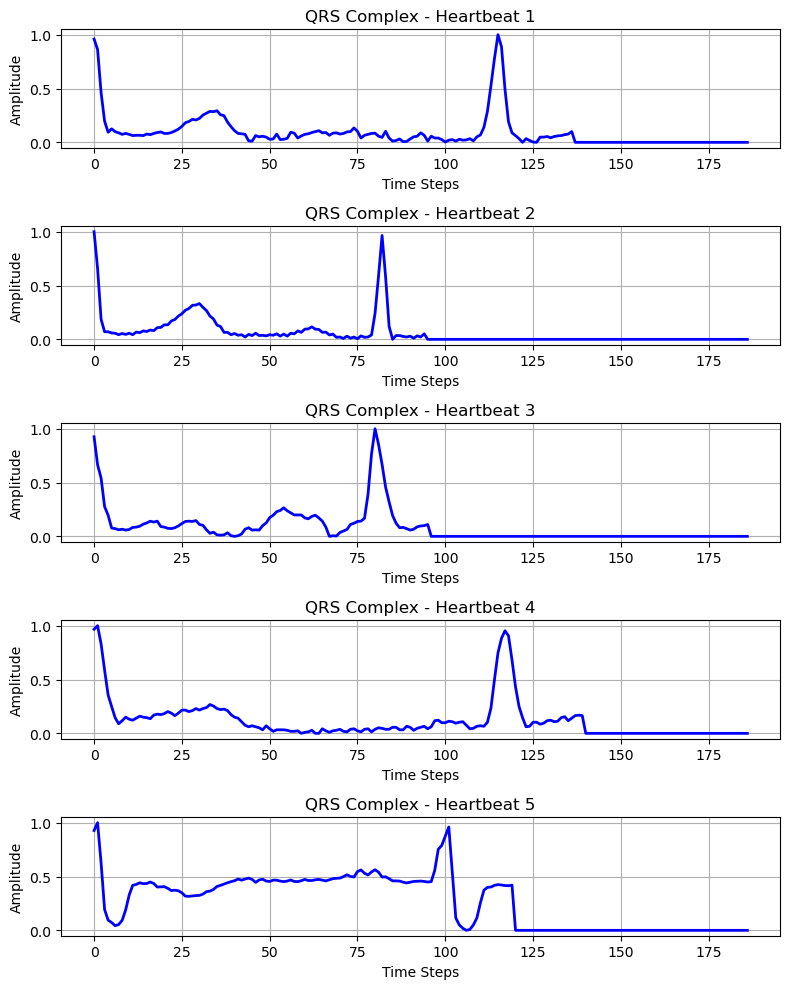

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Select first 5 heartbeats (excluding label column)
num_beats = 5
ecg_samples = mitbih_train.iloc[:num_beats, :-1].values  # First 5 rows, all ECG values

# Time axis (assuming 187 time steps)
time_steps = np.arange(ecg_samples.shape[1])

# Create subplots
fig, axes = plt.subplots(nrows=num_beats, ncols=1, figsize=(8, 10))

for i in range(num_beats):
    axes[i].plot(time_steps, ecg_samples[i], color="blue", linewidth=2)
    axes[i].set_title(f"QRS Complex - Heartbeat {i+1}")
    axes[i].set_xlabel("Time Steps")
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(True)

plt.tight_layout()  # Adjust spacing
plt.show()


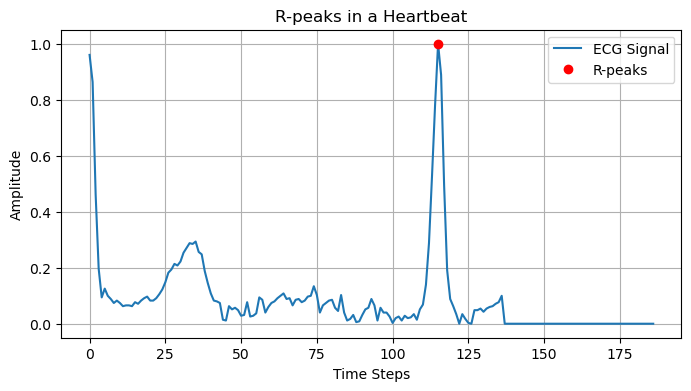

In [33]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# Select one heartbeat for demonstration
heartbeat = mitbih_train.iloc[0, :-1].values  # First row, all ECG values
time_steps = np.arange(len(heartbeat))  # Time axis

# Find R-peaks (detect local maxima)
r_peaks, _ = signal.find_peaks(heartbeat, height=np.max(heartbeat) * 0.5, distance=10)

# Plot the heartbeat with detected R-peaks
plt.figure(figsize=(8, 4))
plt.plot(time_steps, heartbeat, label="ECG Signal")
plt.plot(r_peaks, heartbeat[r_peaks], "ro", label="R-peaks")  # Red dots for R-peaks
plt.xlabel("Time Steps")
plt.ylabel("Amplitude")
plt.title("R-peaks in a Heartbeat")
plt.legend()
plt.grid()
plt.show()

# Calculate QRS duration (time between start and end of QRS complex)
if len(r_peaks) > 1:
    qrs_duration = (r_peaks[-1] - r_peaks[0]) / 360  # Convert to seconds (sampling rate = 360 Hz)
    print(f"Estimated QRS Duration: {qrs_duration:.3f} seconds")


In [35]:
if len(r_peaks) > 1:
    rr_intervals = np.diff(r_peaks) / 360  # Convert to seconds (sampling rate = 360 Hz)
    avg_rr = np.mean(rr_intervals)  # Average RR interval
    heart_rate = 60 / avg_rr  # Convert to BPM (beats per minute)
    
    print(f"✅ Average RR Interval: {avg_rr:.3f} seconds")
    print(f"✅ Estimated Heart Rate: {heart_rate:.1f} BPM")
else:
    print("⚠️ Not enough R-peaks detected to compute heart rate.")


⚠️ Not enough R-peaks detected to compute heart rate.


In [57]:
r_peaks, _ = signal.find_peaks(heartbeat, height=np.max(heartbeat) * 0.5, distance=5)


In [58]:
print(len(r_peaks))

1


In [59]:
heartbeat = mitbih_train.iloc[:5, :-1].values.flatten()  # Use 5 heartbeats instead of 1
time_steps = np.arange(len(heartbeat))


In [60]:
r_peaks, _ = signal.find_peaks(heartbeat, height=np.max(heartbeat) * 0.3, distance=30)


In [61]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, lowcut=0.5, highcut=50, fs=360, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal)

filtered_heartbeat = bandpass_filter(heartbeat)


In [62]:
print(len(r_peaks))

11


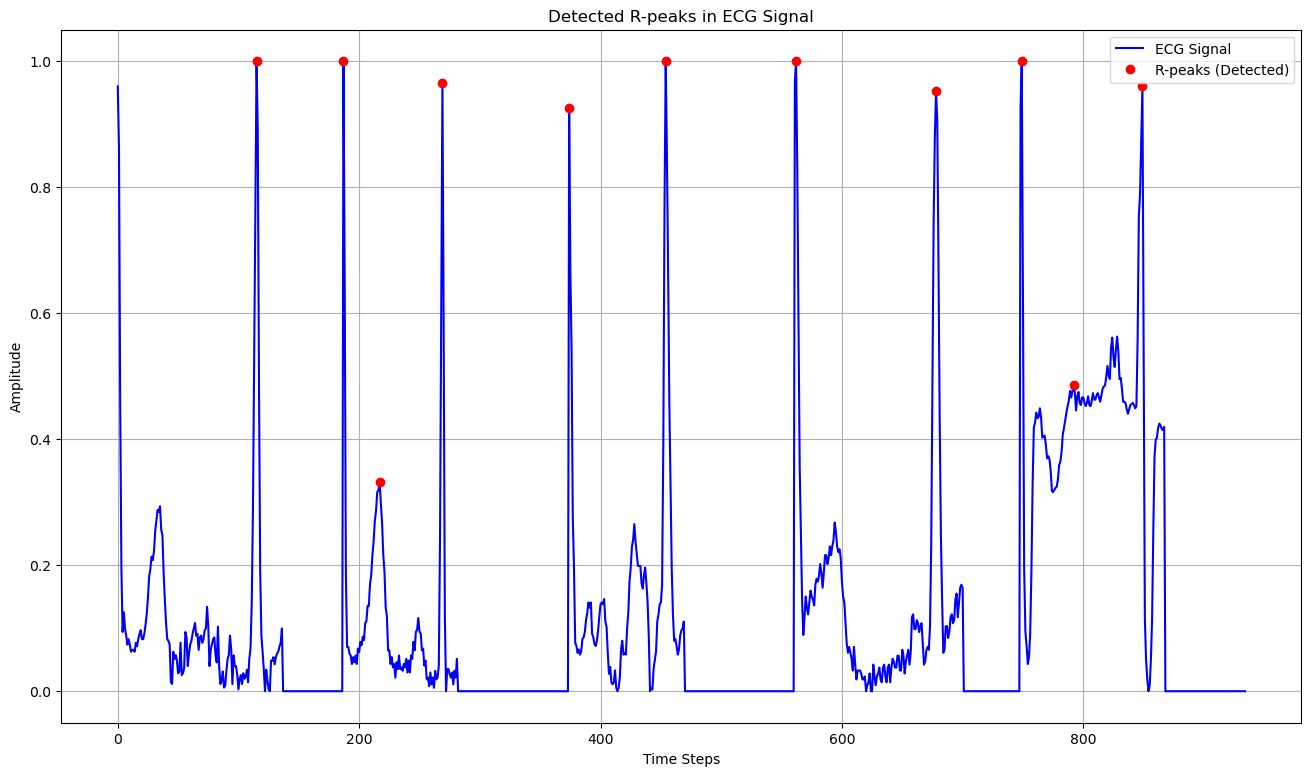

In [64]:
'''import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# Select one ECG segment
heartbeat = mitbih_train.iloc[0, :-1].values  # First row, all ECG values
time_steps = np.arange(len(heartbeat))  # Time axis

# Detect R-peaks
r_peaks, _ = signal.find_peaks(heartbeat, height=np.max(heartbeat) * 0.5, distance=10)'''

# Plot ECG signal with R-peaks
plt.figure(figsize=(16, 9))
plt.plot(time_steps, heartbeat, label="ECG Signal", color="blue")
plt.plot(r_peaks, heartbeat[r_peaks], "ro", label="R-peaks (Detected)")  # Red dots for R-peaks
plt.xlabel("Time Steps")
plt.ylabel("Amplitude")
plt.title("Detected R-peaks in ECG Signal")
plt.legend()
plt.grid()
plt.show()


In [70]:
rr_intervals = np.diff(r_peaks) / 150  # Convert to seconds (sampling rate = 360 Hz)


In [71]:
avg_rr = np.mean(rr_intervals)  # Average RR interval in seconds
print(avg_rr)

0.48933333333333334


In [72]:
heart_rate = 60 / avg_rr  # Convert to beats per minute (BPM)
print(heart_rate)

122.6158038147139


In [73]:
print(f"✅ Average RR Interval: {avg_rr:.3f} seconds")
print(f"✅ Estimated Heart Rate: {heart_rate:.1f} BPM")


✅ Average RR Interval: 0.489 seconds
✅ Estimated Heart Rate: 122.6 BPM
